# 🎯 Targeted Phase 1 Capstone — "Risk Metrics Deep Dive"

---

## 📋 Project Overview

**Goal:** Build a risk analytics module that forces you to understand *why* formulas work, not just implement them.

**Time estimate:** 2.5-3 hours  
**Structure:** 5 parts, each targeting specific weaknesses + validation checkpoints

In [57]:
"""
Risk Metrics Deep Dive — NumPy Implementation
Targets: Statistical foundations, numerical stability, array operations
"""

import numpy as np
import sys  # For memory validation

np.random.seed(42)

# Setup: Generate 252 days of returns for one asset
daily_returns = np.random.randn(252) * 0.015 + 0.0005  # ~15% annual vol, positive drift
print(daily_returns)

[ 7.95071230e-03 -1.57396452e-03  1.02153281e-02  2.33454478e-02
 -3.01230062e-03 -3.01205435e-03  2.41881922e-02  1.20115209e-02
 -6.54211579e-03  8.63840065e-03 -6.45126539e-03 -6.48594630e-03
  4.12943407e-03 -2.81992037e-02 -2.53737675e-02 -7.93431294e-03
 -1.46924668e-02  5.21370999e-03 -1.31203611e-02 -2.06845555e-02
  2.24847315e-02 -2.88664451e-03  1.51292307e-03 -2.08712228e-02
 -7.66574087e-03  2.16383885e-03 -1.67649037e-02  6.13547028e-03
 -8.50958035e-03 -3.87540625e-03 -8.52559918e-03  2.82841728e-02
  2.97541629e-04 -1.53656639e-02  1.28381737e-02 -1.78126547e-02
  3.63295393e-03 -2.88950519e-02 -1.94227907e-02  3.45291854e-03
  1.15769987e-02  3.07052422e-03 -1.23472424e-03 -4.01655543e-03
 -2.16778299e-02 -1.02976631e-02 -6.40958156e-03  1.63568334e-02
  5.65427434e-03 -2.59456023e-02  5.36125954e-03 -5.27623421e-03
 -9.65383000e-03  9.67514433e-03  1.59649928e-02  1.44692018e-02
 -1.20882628e-02 -4.13818564e-03  5.46895147e-03  1.51331769e-02
 -6.68761357e-03 -2.28488

# Part 1 Cumulative Returns

In [25]:
# ========================================
# PART 1: CUMULATIVE RETURNS — THE RIGHT WAY
# Addresses: Q12 (compounding error)
# ========================================

print("=" * 50)
print("PART 1: Cumulative Returns Comparison")
print("=" * 50)

# Task 1.1: Calculate cumulative returns THREE ways
# Method A: Simple sum (WRONG for returns)
cumulative_sum = np.cumsum(daily_returns)

# Method B: Compound product (CORRECT)
cumulative_prod = np.cumprod(1 + daily_returns) - 1

# Method C: Log space (numerically stable for long series)
cumulative_log = np.exp(np.cumsum(np.log(1 + daily_returns))) - 1

# Task 1.2: Compare final values
print(f"Method A (sum):     {cumulative_sum[-1]:.4%}")
print(f"Method B (cumprod): {cumulative_prod[-1]:.4%}")
print(f"Method C (log):     {cumulative_log[-1]:.4%}")

# Task 1.3: Calculate the ERROR between sum and correct method
error = cumulative_sum[-1] - cumulative_prod[-1]
print(f"\nError from using sum: {error:.4%}")

# Task 1.4: EXPLAIN in comments (write this yourself):
# Q: Why does cumsum give the wrong answer?
# A: [YOUR ANSWER HERE - explain the compounding principle in 2-3 sentences]
print("\nCumulative sum produces the produces the wrong return because option A is just simply adding together the daily returns (cumulative sum). The compounding principle dictates that interest is made on interest, i.e it 'compunds'.")

# Q: When does the error become significant?
# A: [YOUR ANSWER HERE - think about magnitude of returns and number of periods]
print("\nThe error becomes more and more significant as you add more periods/number of returns. For example, at a 1% daily return for 10 days, the simple return calculation would give you 10% return. But using the compounding growth principle, this would be 10.4%.")

# Task 1.5: PROOF — Simulate 1000 days with 1% daily returns
# Show that cumsum gives ~1000%, cumprod gives ~2,095,900%
# [WRITE THIS CODE YOURSELF]
print("\nSimulating 1000 days with 1% daily returns using simple and compounding growth calculations:")
daily_returns_1000 = np.ones((1000,))/100
#print(daily_returns_1000)
a = np.cumsum(daily_returns_1000)
b = np.cumprod(1 + daily_returns_1000) - 1

print(f"Method A (sum):     {a[-1]:.4%}")
print(f"Method B (cumprod): {b[-1]:.4%}")
difference = a[-1]-b[-1] #a and b produce arrays. BUT since it is cumlative, you can just take the final element using array[-1]
print(f"Error from using sum: {difference:.4%}")

PART 1: Cumulative Returns Comparison
Method A (sum):     11.1769%
Method B (cumprod): 8.9172%
Method C (log):     8.9172%

Error from using sum: 2.2597%

Cumulative sum produces the produces the wrong return because option A is just simply adding together the daily returns (cumulative sum). The compounding principle dictates that interest is made on interest, i.e it 'compunds'.

The error becomes more and more significant as you add more periods/number of returns. For example, at a 1% daily return for 10 days, the simple return calculation would give you 10% return. But using the compounding growth principle, this would be 10.4%.

Simulating 1000 days with 1% daily returns using simple and compounding growth calculations:
Method A (sum):     1000.0000%
Method B (cumprod): 2095815.5638%
Error from using sum: -2094815.5638%


# Part 2: Volatility Scaling

In [64]:
# ========================================
# PART 2: VOLATILITY SCALING — PROVE IT
# Addresses: Q3, Q15 (sqrt scaling, Sharpe ratio)
# ========================================

print("\n" + "=" * 50)
print("PART 2: Volatility Time-Scaling")
print("=" * 50)

# Task 2.1: Calculate daily volatility
daily_vol = np.std(daily_returns)
print(daily_vol)
print(f"Daily volatility: {daily_vol:.4%}")

# Task 2.2: Annualize using sqrt(252)
annual_vol_formula = daily_vol * np.sqrt(252)
print(f"Annual vol (formula): {annual_vol_formula:.4%}")
# What we're doing in task 2.1 and task 2.2 is calculating the annualised volatility.
# We do this first by producing an array of the std dev of each day... (since the original is DAILY returns)
# THEN we 'annualise it'. We do this by * it against the square root of 252 - this is because it scales with the sqrt of time. (See notes in end-of-phase-test.ipynb or in m7-stats-and-aggregation-functions)


# Task 2.3: PROVE IT — Simulate 1000 different years (252 days each)
# For each year, calculate the annual return
# Then take the std of those annual returns
# This should match your formula within sampling error

# [WRITE THIS SIMULATION YOURSELF]
# Hint: Create array of shape (1000, 252) with random returns

#1 Setup: Generating 252 days of returns for one asset, 1000 different years
daily_returns_1000sample = np.random.randn(1000, 252) * daily_vol
print(f"Year of Daily Returns incl. a daily volatility of {daily_vol:.4%}:", daily_returns_1000sample)

#2 Annual Return: Calculating annual return for each 1000 years
    #axis=1 compounds ACROSS the days within each year
annual_return_1000sample = np.cumprod(1+daily_returns_1000sample,axis=1)-1

#3 VOLATILITY using Std Dev: Calculating Std Dev for each 1000 years
#since this is cumulative, we only want the last element in the array, for each of the 1000 years. 
final_annual_return = annual_return_1000sample[:,-1] #Shape of (1000,)
final_simulated_volatility = np.std(final_annual_return)
print("Calculated Volatility (using Std Dev.)", final_simulated_volatility) #1000, 0

#Here we are comparing 
simulated_vol_vs_actual = (daily_vol * np.sqrt(252)) - final_simulated_volatility
print("The difference between simulated volatility and annual volatility (daily volatility * np.sqrt(252)): ", simulated_vol_vs_actual)
        # Should be super similar!


# Task 2.4: EXPLAIN in comments:
# Q: Why sqrt(252) and not just 252?
# A: [YOUR ANSWER - explain variance scaling linearly, vol scaling with sqrt]
"""
Variance is (Std Dev)^2, and since std dev itself is square rooted, they cancel out.
This means that it scales linearly with time. Since Volatility is measured by Std Dev (which is sqrd) - this means it scales with sqrt over time. 
In Task 2.1 and 2.2 we are showing that take place by taking the Std Dev of Daily Returns to get the volatility, an annualising it by multiplying it with sqrt(252) to make it linear. (see graphing below)
    std([day 1, day 2, ..., day 126]) × sqrt(126) ≈ 6-month volatility


In Task 2.3 we are getting daily returns with volatility already 'baked in', and getting the annualised return (using cumulative prod), and then looking at the 'annualised volatility' across a range of different 'simulated' years (since you cant do std deviation on just one number).
    Period 1: [day 1, day 2, ..., day 126] → cumulative return = 8%
    Period 2: [day 1, day 2, ..., day 126] → cumulative return = 12%
    Period 3: [day 1, day 2, ..., day 126] → cumulative return = -3%
    ...
    Period 1000: [day 1, day 2, ..., day 126] → cumulative return = 5%

    std([8%, 12%, -3%, ..., 5%]) = 6-month volatility   


    
"""


# Task 2.5: Calculate Sharpe ratio (assume 2% risk-free rate)
annual_return = np.mean(daily_returns) * 252
risk_free = 0.02
sharpe = (annual_return - risk_free) / annual_vol_formula
print(f"\nSharpe Ratio: {sharpe:.2f}")

# Task 2.6: EXPLAIN in comments:
# Q: Why multiply by sqrt(252) at the end, not divide?
# A: [YOUR ANSWER - show the algebra]
"""

Start with the definition:
Sharpe = (Annual Return - Risk Free) / Annual Volatility


Substitute the annualization formulas:
Sharpe = [mean(daily) * 252 - rf] / [std(daily) * √252]

Assume risk-free is already annual (0.02), and mean is small so we can ignore it in rf:

Sharpe ≈ [mean(daily) * 252] / [std(daily) * √252]


Factor out the daily ratio:
Sharpe = [mean(daily) / std(daily)] * [252 / √252]


Simplify:
Sharpe = [mean(daily) / std(daily)] * √252


**The √252 appears because:**
- Numerator scales by **252** (returns scale linearly)
- Denominator scales by **√252** (volatility scales with sqrt)
- Ratio = 252 / √252 = √252 


"""



PART 2: Volatility Time-Scaling
0.014479414903618738
Daily volatility: 1.4479%
Annual vol (formula): 22.9854%
Year of Daily Returns incl. a daily volatility of 1.4479%: [[ 0.02111904  0.01865191 -0.00505653 ...  0.02868693  0.00439418
  -0.01154646]
 [-0.00067758  0.00194602  0.00374292 ... -0.002195    0.00468533
   0.01209325]
 [ 0.0139816  -0.03589325  0.02378411 ...  0.00839659  0.03157476
  -0.01091292]
 ...
 [-0.00912609 -0.01319388  0.02449233 ...  0.00076332  0.01098861
   0.00870887]
 [ 0.00222041 -0.03062572  0.00876012 ... -0.00286374  0.01774176
   0.00473016]
 [ 0.01817132 -0.00675632  0.02163637 ... -0.02167256 -0.01337252
  -0.00851977]]
Calculated Volatility (using Std Dev.) 0.22890341496590091
The difference between simulated volatility and annual volatility (daily volatility * np.sqrt(252)):  0.0009501708222837968

Sharpe Ratio: 0.40


'\n\nStart with the definition:\nSharpe = (Annual Return - Risk Free) / Annual Volatility\n\n\nSubstitute the annualization formulas:\nSharpe = [mean(daily) * 252 - rf] / [std(daily) * √252]\n\nAssume risk-free is already annual (0.02), and mean is small so we can ignore it in rf:\n\nSharpe ≈ [mean(daily) * 252] / [std(daily) * √252]\n\n\nFactor out the daily ratio:\nSharpe = [mean(daily) / std(daily)] * [252 / √252]\n\n\nSimplify:\nSharpe = [mean(daily) / std(daily)] * √252\n\n\n**The √252 appears because:**\n- Numerator scales by **252** (returns scale linearly)\n- Denominator scales by **√252** (volatility scales with sqrt)\n- Ratio = 252 / √252 = √252 \n\n\n'

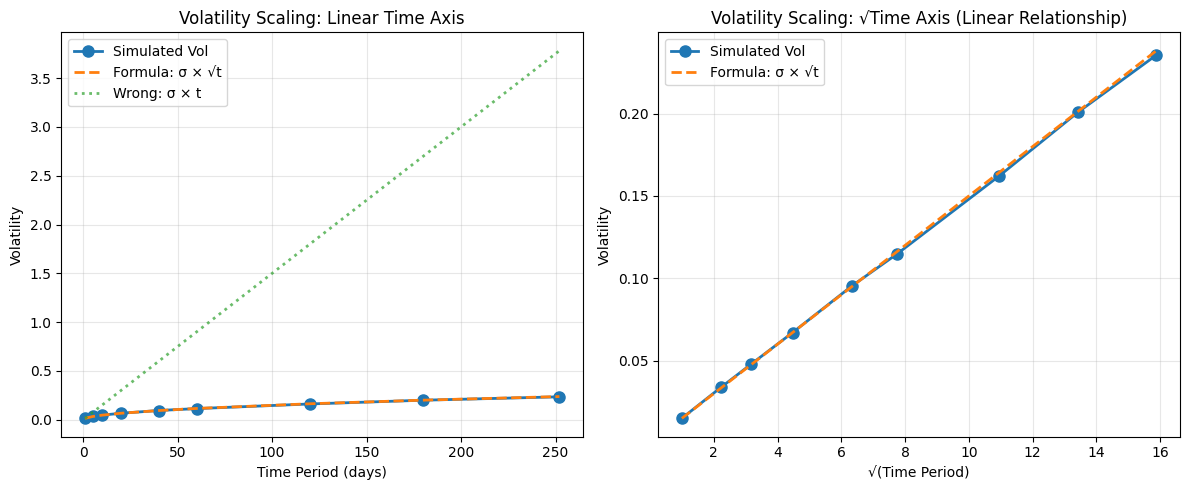

Graph saved as 'volatility_scaling.png'

Daily vol: 0.0150
252-day vol (formula): 0.2381
252-day vol (simulated): 0.2354


In [ ]:
#PLOTTING VOLATILTIY SCALING

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Base parameters
daily_vol = 0.015  # 1.5% daily volatility
n_simulations = 10000  # More simulations = smoother curve

# Different time periods to test (in days)
time_periods = np.array([1, 5, 10, 20, 40, 60, 120, 180, 252])

# Store results
simulated_vols = []

# For each time period, simulate many paths and measure volatility
for t in time_periods:
    # Simulate n_simulations paths, each t days long
    returns = np.random.randn(n_simulations, t) * daily_vol
    
    # Calculate cumulative return for each path
    cumulative_returns = np.sum(returns, axis=1)  # Simple sum for this example
    
    # Measure volatility of those cumulative returns
    vol_at_t = np.std(cumulative_returns)
    simulated_vols.append(vol_at_t)

simulated_vols = np.array(simulated_vols)

# Formula predictions
vol_sqrt_t = daily_vol * np.sqrt(time_periods)  # Correct: sqrt scaling
vol_linear_t = daily_vol * time_periods  # Wrong: linear scaling

# Create the plot
plt.figure(figsize=(12, 5))

# Plot 1: Volatility vs Time (linear x-axis)
plt.subplot(1, 2, 1)
plt.plot(time_periods, simulated_vols, 'o-', label='Simulated Vol', markersize=8, linewidth=2)
plt.plot(time_periods, vol_sqrt_t, '--', label='Formula: σ × √t', linewidth=2)
plt.plot(time_periods, vol_linear_t, ':', label='Wrong: σ × t', linewidth=2, alpha=0.7)
plt.xlabel('Time Period (days)')
plt.ylabel('Volatility')
plt.title('Volatility Scaling: Linear Time Axis')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Volatility vs √Time (sqrt x-axis)
plt.subplot(1, 2, 2)
sqrt_time = np.sqrt(time_periods)
plt.plot(sqrt_time, simulated_vols, 'o-', label='Simulated Vol', markersize=8, linewidth=2)
plt.plot(sqrt_time, vol_sqrt_t, '--', label='Formula: σ × √t', linewidth=2)
plt.xlabel('√(Time Period)')
plt.ylabel('Volatility')
plt.title('Volatility Scaling: √Time Axis (Linear Relationship)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('volatility_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

print("Graph saved as 'volatility_scaling.png'")
print(f"\nDaily vol: {daily_vol:.4f}")
print(f"252-day vol (formula): {daily_vol * np.sqrt(252):.4f}")
print(f"252-day vol (simulated): {simulated_vols[-1]:.4f}")

# Part 3: VAR Calculation

In [85]:
# ========================================
# PART 3: VAR CALCULATION — AXIS MASTERY
# Addresses: Q2, Q7, Q8 (axis operations, broadcasting)
# ========================================

print("\n" + "=" * 50)
print("PART 3: Value at Risk — Multi-Asset")
print("=" * 50)

# Task 3.1: Simulate 5 assets, 252 days
n_assets = 5
returns_multi = np.random.randn(252, n_assets) * 0.015 + 0.0005

# Validate shape
print(f"Returns shape: {returns_multi.shape}")
# Q: Which dimension is days, which is assets?
# A: [YOUR ANSWER]
print("The vertical dimension is days, the horizontal is assets.")

# Task 3.2: Calculate mean return for EACH ASSET (across all days)
# Use np.mean with correct axis parameter
asset_means = np.mean(returns_multi, axis=0)  # Fill in the ???
print(f"Asset means shape: {asset_means.shape}")  # Should be (5,)
print(f"Asset means: {asset_means}")

# Task 3.3: Calculate std for EACH ASSET
asset_stds = np.std(returns_multi, axis=0)  # Fill in the ???
print(f"Asset stds shape: {asset_stds.shape}")  # Should be (5,)

# Task 3.4: Z-score normalization (standardize each asset)
# normalized = (returns - mean) / std
# This is where broadcasting happens!
normalized = (returns_multi - asset_means) / asset_stds

# Task 3.5: EXPLAIN the broadcasting:
# Q: What shapes are being broadcast in the subtraction?
# A: [YOUR ANSWER - be specific about (252, 5) - (5,) → (252, 5)]
"""
The shapes being broadcasted here are:
returns_multi - shape: (252,5) rows, columns | days, stocks
asset_means - shape: (5,) rows, columns | stocks, 0

Therefore, what it is doing is subtracting the mean of each stock, across the row, down all of the 252 trading days.

"""

# Task 3.6: Find days where ANY asset exceeded 2 std deviations.
    # Z-score are measured by Std Deviations. E.g Z-score = 2 = 2StdDevs above the mean
    # so I can use the nomalised values array we made
# Use np.abs and boolean operation

outlier_mask =  np.abs(normalized) > 2  # [YOUR CODE]
outlier_indices = np.where(outlier_mask)
print(f"\nFound {len(outlier_indices[0])} outlier days")


# Task 3.7: Calculate 5% VaR for each asset
# VaR = 5th percentile of returns (the threshold below which 5% of returns fall)
var_5 = np.percentile(returns_multi, 5, axis=0)  # Fill in the ???
print(f"5% VaR per asset: {var_5}")






PART 3: Value at Risk — Multi-Asset
Returns shape: (252, 5)
The vertical dimension is days, the horizontal is assets.
Asset means shape: (5,)
Asset means: [0.00117365 0.00077416 0.00191169 0.00069662 0.00118911]
Asset stds shape: (5,)

Found 56 outlier days
5% VaR per asset: [-0.0242631  -0.02298559 -0.02336791 -0.02410132 -0.02433279]


# PART 4: Memoery & DTYPE Discipline

In [ ]:
# ========================================
# PART 4: MEMORY & DTYPE DISCIPLINE
# Addresses: Q14 (calculation errors)
# ========================================

print("\n" + "=" * 50)
print("PART 4: Memory Calculation & Validation")
print("=" * 50)

# Task 4.1: Calculate memory for 500 stocks, 20 years daily data
n_stocks = 500
n_years = 20
days_per_year = 252

# Total data points = ???  [CALCULATE THIS]
total_points = 500*20*252

# Memory for float64 (8 bytes each, per data point so you must *)
memory_float64_bytes = total_points * 8  # [YOUR CALCULATION]
memory_float64_mb = memory_float64_bytes / (1024 ** 2)

# Memory for float32 (4 bytes each, same as above)
memory_float32_bytes = total_points * 4  # [YOUR CALCULATION]
memory_float32_mb = memory_float32_bytes / (1024 ** 2)

print(f"Data points: {total_points:,}")
print(f"Float64: {memory_float64_mb:.2f} MB")
print(f"Float32: {memory_float32_mb:.2f} MB")
print(f"Difference: {memory_float64_mb - memory_float32_mb:.2f} MB")

# Task 4.2: VALIDATE your calculation
# Create actual arrays and check with sys.getsizeof
test_array_64 = np.random.randn(total_points).astype(np.float64)
test_array_32 = np.random.randn(total_points).astype(np.float32)

actual_64_mb = sys.getsizeof(test_array_64) / (1024 ** 2)
actual_32_mb = sys.getsizeof(test_array_32) / (1024 ** 2)

print(f"\nValidation:")
print(f"Actual Float64: {actual_64_mb:.2f} MB")
print(f"Actual Float32: {actual_32_mb:.2f} MB")

# Task 4.3: EXPLAIN
# Q: Does your calculation match sys.getsizeof? If not, why?
# A: [YOUR ANSWER - small overhead from NumPy metadata]
"""""
My calculation does match the sys.getsizeof! I image thought that if I was to save it, it may be slightly smaller than my saved version, because my saved version might have some attached metadata
"""""


# Task 4.4: When does this matter on your 16GB M5?
# Q: How many stocks could you load in memory (20 years daily) with Float64?
# A: [YOUR CALCULATION AND REASONING]
"""
Converting 16GB to bytes:
16GB = 16,0000,000,000,000 bytes


Calculating Total trading Days:
Total Trading days = 252 * 20 = 5040 bytes

3,174,603 stocks                              


"""


PART 4: Memory Calculation & Validation
Data points: 2,520,000
Float64: 19.23 MB
Float32: 9.61 MB
Difference: 9.61 MB

Validation:
Actual Float64: 19.23 MB
Actual Float32: 9.61 MB


# Part 5: Numerical Stabiltiy

In [ ]:
# ========================================
# PART 5: NUMERICAL STABILITY — VARIANCE
# Addresses: Q16, Q17, Q20 (catastrophic cancellation, precision)
# ========================================

print("\n" + "=" * 50)
print("PART 5: Numerical Stability")
print("=" * 50)

# Task 5.1: Calculate variance two ways
returns_test = daily_returns - daily_returns.mean()  # Center the data

# Method A: Direct formula
var_a = np.mean(returns_test**2) - np.mean(returns_test)**2

# Method B: NumPy built-in
var_b = np.var(returns_test)

print(f"Variance Method A: {var_a:.10f}")
print(f"Variance Method B: {var_b:.10f}")
print(f"Difference: {abs(var_a - var_b):.2e}")

# Task 5.2: Create a case where Method A fails
# Generate returns with large mean, small variance
# Example: mean = 1000, std = 0.001
bad_returns = np.random.randn(1000) * 0.001 + 1000

var_a_bad = np.mean(bad_returns**2) - np.mean(bad_returns)**2
var_b_bad = np.var(bad_returns)

print(f"\nWith large mean:")
print(f"Variance Method A: {var_a_bad:.10f}")
print(f"Variance Method B: {var_b_bad:.10f}")

# Task 5.3: EXPLAIN
# Q: Why does Method A give a negative or wildly wrong variance here?
# A: [YOUR ANSWER - explain catastrophic cancellation]

# Task 5.4: Float32 precision loss
# Create an array of 1 million small returns
small_returns = np.random.randn(1_000_000) * 0.0001  # Very small returns

# Calculate mean in float64 vs float32
mean_64 = np.mean(small_returns.astype(np.float64))
mean_32 = np.mean(small_returns.astype(np.float32))

print(f"\nFloat64 mean: {mean_64:.10f}")
print(f"Float32 mean: {mean_32:.10f}")
print(f"Difference: {abs(mean_64 - mean_32):.2e}")

# Task 5.5: EXPLAIN
# Q: Under what conditions does float32 give materially wrong results?
# A: [YOUR ANSWER - averaging many small values, precision loss in sum]

# Part 6: Synthesis

In [ ]:
# ========================================
# PART 6: SYNTHESIS — YOUR INSIGHTS
# ========================================

print("\n" + "=" * 50)
print("PART 6: What You Learned")
print("=" * 50)

# Write 5 sentences (one for each part):
# 1. Cumulative returns: [What did you learn about compounding?]
# 2. Volatility scaling: [Why does sqrt(time) matter?]
# 3. Axis operations: [How do you remember which axis to use?]
# 4. Memory calculation: [When does dtype choice matter?]
# 5. Numerical stability: [What's the biggest risk when calculating variance?]

## ✅ What Makes This Capstone Targeted

**Addresses your weaknesses:**
- **Q3, Q15 (volatility scaling):** Part 2 makes you PROVE sqrt(252) through simulation
- **Q12 (compounding):** Part 1 forces you to compare sum vs cumprod explicitly
- **Q2, Q7, Q8 (axis operations):** Part 3 requires correct axis parameters with shape validation
- **Q14 (memory calculation):** Part 4 makes you calculate AND validate with actual arrays
- **Q5 (log returns):** Part 1 includes log-space method for long series
- **Q16, Q17, Q20 (numerical stability):** Part 5 shows catastrophic cancellation and precision loss

**Reinforces your strengths:**
- Vectorization wins throughout (you already get this)
- Efficiency comparisons (playing to Q1, Q10 strengths)
- Clean, professional code structure

**Critical difference from other capstones:**
- You must EXPLAIN every calculation in comments (not just code it)
- You must VALIDATE calculations (Part 4's sys.getsizeof check)
- You must PROVE concepts through simulation (Parts 1, 2)

---

## 📝 Deliverables

When you're done, I want:

1. **Complete working code** (copy-paste runnable)
2. **All the ??? filled in** with correct values
3. **All [YOUR ANSWER] comments** filled with your explanations
4. **The 5 synthesis sentences** at the end

---

## 🎯 Success Criteria

You'll know you're ready for Phase 2 when:
- ✅ You can explain WHY sqrt(252), not just USE it
- ✅ You can predict array shapes before running code
- ✅ You can calculate memory requirements without checking
- ✅ You understand when numerical stability matters